In [3]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import importlib
import dataset
from image_builder import *
from data_prepare import *
import data_fetch
from data_fetch import *
from data_fetch import _download_single, _read_mops_csv

importlib.reload(dataset)
importlib.reload(data_fetch)

<module 'data_fetch' from '/home/iof_314707035/Jasper/Reimage_price_trends/data_fetch.py'>

In [4]:
from dataset import *
import os

START = "1993-01-01"
END = "2019-12-31"
TRAIN_END = "2000-12-31"
SAVE_DIR = "data"
Market = "US_1993_2020"
I = 5
R = 5
CRSP_DATA_DIR = resolve_crsp_data_dir()
print("CRSP data dir:", CRSP_DATA_DIR)

TICKERS, crsp_info = get_crsp_permno_universe(
    crsp_data_dir=CRSP_DATA_DIR,
    start=START,
    end=END,
    return_info=True,
)

print("permno 數量:", len(TICKERS))
display(crsp_info.head())

CRSP data dir: us_stock
permno 數量: 20721


,ticker,permno,first_year,last_year,rows
0,10001,10001,1993,2017,5666
1,10002,10002,1993,2013,3873
2,10003,10003,1993,1995,665
3,10009,10009,1993,2000,1347
4,10010,10010,1993,1995,670


In [ ]:

# X_trainval, y_trainval, X_test, y_test, meta = build_research_dataset(
#     tickers=TICKERS,
#     start=START,
#     end=END,
#     I=I,
#     R=R,
#     train_end=TRAIN_END,
#     save_dir=SAVE_DIR,
#     Market=Market,
#     price_source="crsp",
#     crsp_data_dir=CRSP_DATA_DIR,
#     checkpoint_every=1,
#     resume=False,
#     process_by="year",
#     checkpoint_save_arrays=False,
#     year_ticker_chunk_size=1000,
#     max_workers=8,
# )



Year-based CRSP build: pending years=[1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]

[I5/R5] build year: 1993


year 1993 chunks:   0%|          | 0/21 [00:00<?, ?it/s]

year 1993 chunks:   0%|          | 0/21 [00:02<?, ?it/s]


KeyboardInterrupt: 

In [5]:
I = 5
R = 5
Market = "US_1993_2020"

dataset_dir = f"data/training_data/{Market}/I{I}R{R}S{R}_week"

X_trainval = np.load(f"{dataset_dir}/X_trainval.npy")
y_trainval = np.load(f"{dataset_dir}/y_trainval.npy")

X_test = np.load(f"{dataset_dir}/X_test.npy")
y_test = np.load(f"{dataset_dir}/y_test.npy")

meta = pd.read_csv(f"{dataset_dir}/meta.csv")
meta_trainval = pd.read_csv(f"{dataset_dir}/meta_trainval.csv")
meta_test = pd.read_csv(f"{dataset_dir}/meta_test.csv")

print("X_trainval:", X_trainval.shape)
print("y_trainval:", y_trainval.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("meta_trainval:", meta_trainval.shape)
print("meta_test:", meta_test.shape)

display(meta.head())



X_trainval: (3177623, 32, 15)
y_trainval: (3177623,)
X_test: (5899718, 32, 15)
y_test: (5899718,)
meta_trainval: (3177623, 12)
meta_test: (5899718, 12)


,ticker,start_date,date,label_end_date,label,ret,I,R,sample_step,sample_freq,price_source,ending_date
0,10001,1993-01-14,1993-01-22,1993-02-12,0,-0.035703,5,5,5,week,crsp,1993-01-22
1,10001,1993-02-02,1993-02-12,1993-02-26,1,0.036033,5,5,5,week,crsp,1993-02-12
2,10001,1993-02-12,1993-02-26,1993-03-12,1,0.038308,5,5,5,week,crsp,1993-02-26
3,10001,1993-03-08,1993-03-12,1993-04-08,0,-0.070042,5,5,5,week,crsp,1993-03-12
4,10001,1993-03-25,1993-04-08,1993-04-16,1,0.044248,5,5,5,week,crsp,1993-04-08


In [10]:
import model
importlib.reload(model)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


RUN_SEEDS = list(range(1))
ENSEMBLE_DIR = f"models/{Market}/I{I}R{R}"
EPOCHS = 50
BATCH_SIZE = 256
VAL_RATIO = 0.3

ensemble_results = model.train_resplit_ensemble(
    X_trainval=X_trainval,
    y_trainval=y_trainval,
    I=I,
    R=R,
    seeds=RUN_SEEDS,
    save_dir=ENSEMBLE_DIR,
    Market=Market,
    val_ratio=VAL_RATIO,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=1e-4,
    weight_decay=0,
    device=device,
)


Using device: cuda


ensemble runs: 100%|██████████| 1/1 [36:31<00:00, 2191.60s/it, seed=0]


In [ ]:
# import torch
# import pandas as pd
# import matplotlib.pyplot as plt


# result = pd.read_csv("/home/iof_314707035/Jasper/Reimage_price_trends/models/US_1993_2020/I5R5/US_1993_2020_training_history_I5R5_seed0.csv")

# plt.figure(figsize=(8, 5))
# plt.plot(result["epoch"], result["val_loss"], label="val_loss", marker="o")
# plt.xlabel("Epoch")
# plt.xticks(result["epoch"])
# plt.ylabel("Loss")
# plt.title("Training / Validation Loss")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()


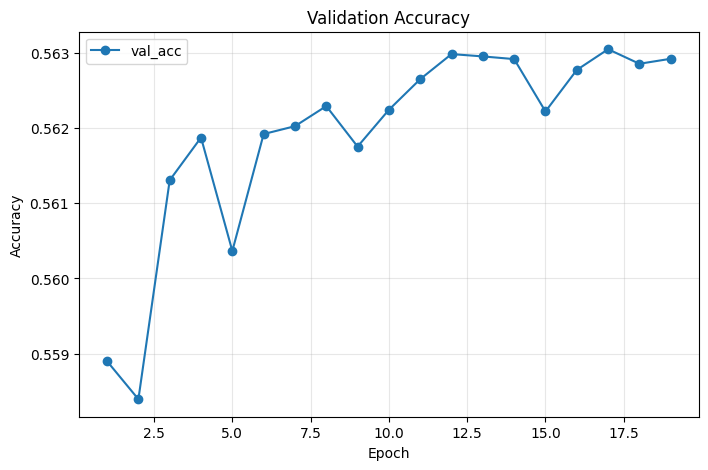

In [ ]:
# plt.figure(figsize=(8, 5))
# plt.plot(result["epoch"], result["val_acc"], label="val_acc", marker="o")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.title("Validation Accuracy")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# Test

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, accuracy_score, log_loss
import model
import importlib
importlib.reload(model)

root = Path("/home/iof_314707035/Jasper")

# 1. 讀取 test data
market = "US_1993_2020"
dataset_dir = root / "Reimage_price_trends" / "data" / "training_data" / market / "I5R5S5_week"

X_test = np.load(dataset_dir / "X_test.npy")
y_test = np.load(dataset_dir / "y_test.npy")

print(X_test.shape, y_test.shape)


(5899718, 32, 15) (5899718,)


In [7]:
model_dir = root / "Reimage_price_trends" / "models" / "US_1993_2020" / "I5R5"
RUN_SEEDS = list(range(1))
seeds = list(RUN_SEEDS)

summary_frames = []
checkpoint_paths = []
for seed in seeds:
    summary_path = model_dir / f"US_1993_2020_training_summary_I5R5_seed{seed}.csv"
    summary_df = pd.read_csv(summary_path)
    best_path = Path(summary_df.loc[0, "best_path"])
    if not best_path.is_absolute():
        best_path = root / "Reimage_price_trends" / best_path
    checkpoint_paths.append(str(best_path))
    summary_frames.append(summary_df.assign(seed=seed, resolved_best_path=str(best_path)))

ensemble_summary_df = pd.concat(summary_frames, ignore_index=True)
print("ensemble checkpoints:")
for path in checkpoint_paths:
    print(path)


ensemble checkpoints:
/home/iof_314707035/Jasper/Reimage_price_trends/models/US_1993_2020/I5R5/US_1993_2020_best_model_I5R5_seed0.pth


In [9]:
years_test = pd.to_datetime(meta_test["date"]).dt.year.to_numpy()
pred_prob = model.average_ensemble_predictions(
    X_test,
    checkpoint_paths,
    batch_size=256,
    device="cuda",
    years=years_test,
)

pred_prob = np.asarray(pred_prob).reshape(-1)
pred_label = (pred_prob > 0.5).astype(int)


/home/iof_314707035/miniconda3/envs/reimage-price-trends/lib/python3.11/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.5) - (12.0)
    
  queued_call()


In [ ]:
# test_mse = mean_squared_error(y_test, pred_prob)
# test_acc = accuracy_score(y_test, pred_label)
# test_logloss = log_loss(y_test, pred_prob)

# print("ensemble checkpoints:", len(checkpoint_paths))
# print("test MSE:", test_mse)
# print("test accuracy:", test_acc)
# print("test logloss:", test_logloss)


ensemble checkpoints: 1
test MSE: 0.2502518594264984
test accuracy: 0.5136823488851501
test logloss: 0.6936732470178055


In [10]:
import pandas as pd
import portfolio_backtest as pb
importlib.reload(pb)

pred_df = pb.make_prediction_frame(
    meta=meta_test,
    y_true=y_test,
    pred_prob=pred_prob,
    pred_label_threshold=0.5,
)


seed_tag = "seed" + "_".join(str(seed) for seed in seeds)
run_dir = model_dir / f"ensemble_{seed_tag}"
grouped_df, portfolio_returns, summary = pb.run_decile_backtest(
    pred_df,
    n_groups=10,
    R=5,
    output_dir=str(run_dir / "backtest_ensemble_mean_prob"),
    prefix="i5r5_ensemble_mean_prob",
    transaction_cost=True,
    transaction_cost_bps=1.0,
    mid_cap_transaction_cost_bps=5.0,
    small_cap_transaction_cost_bps=10.0
)

summary

,strategy,n_periods,periods_per_year,annualization_method,mean_period_return,period_volatility,annualized_return,annualized_volatility,sharpe,compound_annualized_return,compound_sharpe,cumulative_return,max_drawdown,positive_period_rate
0,long_top_ret,991,52.0,js_cnn,0.009469,0.029720,0.492365,0.214314,2.297401,0.632395,2.297401,7.423459e+03,-0.354274,0.677094
1,short_bottom_ret,991,52.0,js_cnn,0.004725,0.020517,0.245682,0.147952,1.660550,0.277753,1.660550,8.623567e+01,-0.352461,0.572149
2,long_short_ret,991,52.0,js_cnn,0.014193,0.017636,0.738047,0.127172,5.803550,1.081020,5.803550,1.006514e+06,-0.033536,0.884965
3,long_top_net_ret,991,52.0,js_cnn,0.008376,0.029705,0.435531,0.214206,2.033238,0.542982,2.033238,2.535471e+03,-0.371924,0.659939
4,short_bottom_net_ret,991,52.0,js_cnn,0.006224,0.020526,0.323666,0.148018,2.186668,0.380800,2.186668,3.816571e+02,-0.323780,0.612513
5,long_short_net_ret,991,52.0,js_cnn,0.014600,0.017638,0.759197,0.127193,5.968870,1.124865,5.968870,1.497676e+06,-0.033014,0.891019


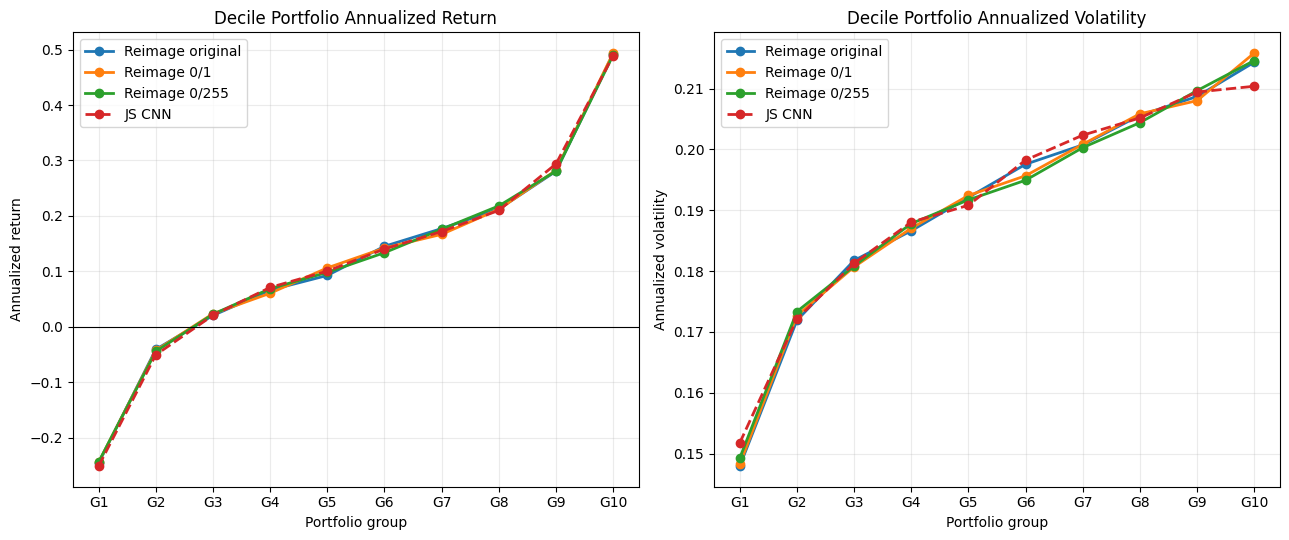

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

reimage_dir = Path(
    "/home/iof_314707035/Jasper/Reimage_price_trends/models/US_1993_2020/I5R5/ensemble_seed0/backtest_ensemble_mean_prob"
)

js_path = Path(
    "/home/iof_314707035/Jasper/WORK_SPACE/new_model_res/portfolio/"
    "USA_D5L2F53S11D11MP21F53S11D11MP21C64_5d5p-lr1E-04-dp0.50-maTrue-vbTrue-weeklyTrained-noDelayedReturn_ensem10_noDelayedReturn/ew.csv"
)

reimage_files = {
    "Reimage original": reimage_dir / "i5r5_ensemble_mean_prob_portfolio_returns.csv",
    "Reimage 0/1": reimage_dir / "i5r5_ensemble_mean_prob_portfolio_returns_0_1.csv",
    "Reimage 0/255": reimage_dir / "i5r5_ensemble_mean_prob_portfolio_returns_0_255.csv",
}

periods_per_year = 52
groups = np.arange(1, 11)

def annual_group_stats(path):
    df = pd.read_csv(path)
    rows = []
    for g in groups:
        r = pd.to_numeric(df[f"group_{g}_ret"], errors="coerce").dropna()
        rows.append({
            "group": g,
            "annualized_return": r.mean() * periods_per_year,
            "annualized_std": r.std() * np.sqrt(periods_per_year),
        })
    return pd.DataFrame(rows)

plot_data = {
    name: annual_group_stats(path)
    for name, path in reimage_files.items()
}

js_df = pd.read_csv(js_path)
js_deciles = js_df.iloc[:10].copy()
js_deciles["group"] = groups
js_deciles["ret"] = pd.to_numeric(js_deciles["ret"], errors="coerce")
js_deciles["std"] = pd.to_numeric(js_deciles["std"], errors="coerce")

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

for name, df in plot_data.items():
    ax[0].plot(df["group"], df["annualized_return"], marker="o", linewidth=2, label=name)
    ax[1].plot(df["group"], df["annualized_std"], marker="o", linewidth=2, label=name)

ax[0].plot(js_deciles["group"], js_deciles["ret"], marker="o", linewidth=2, linestyle="--", label="JS CNN")
ax[1].plot(js_deciles["group"], js_deciles["std"], marker="o", linewidth=2, linestyle="--", label="JS CNN")

ax[0].axhline(0, color="black", linewidth=0.8)
ax[0].set_xticks(groups)
ax[0].set_xticklabels([f"G{g}" for g in groups])
ax[0].set_xlabel("Portfolio group")
ax[0].set_ylabel("Annualized return")
ax[0].set_title("Decile Portfolio Annualized Return")
ax[0].legend()
ax[0].grid(alpha=0.25)

ax[1].set_xticks(groups)
ax[1].set_xticklabels([f"G{g}" for g in groups])
ax[1].set_xlabel("Portfolio group")
ax[1].set_ylabel("Annualized volatility")
ax[1].set_title("Decile Portfolio Annualized Volatility")
ax[1].legend()
ax[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

Detected Jasper root: /home/iof_314707035/Jasper


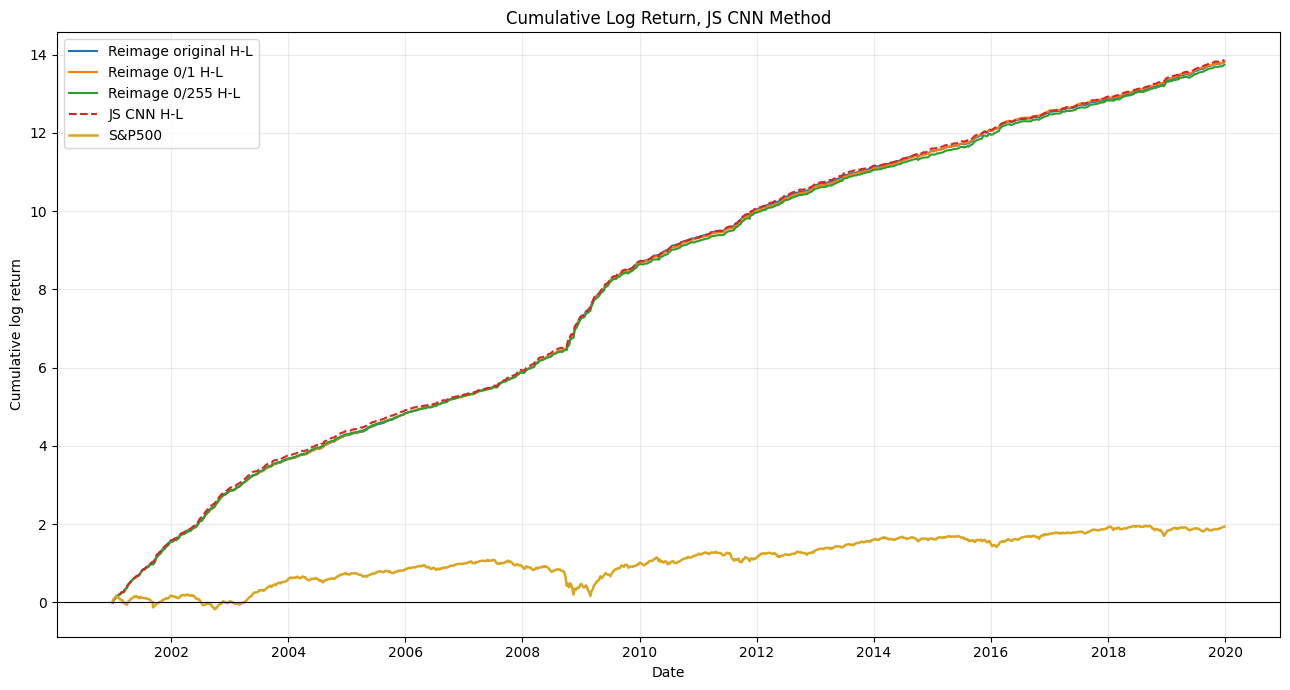

Date range: 2001-01-05 to 2019-12-27
Overlapping periods: 991


,annual_return,annual_std,sharpe_no_rf,final_cum_log_return,final_cum_simple_return
Reimage_H-L,0.738047,0.127172,5.803550,13.822005,1.006514e+06
Reimage_H-L_0_1,0.738237,0.127567,5.787057,13.824536,1.009065e+06
Reimage_H-L_0_255,0.733872,0.126117,5.818989,13.745758,9.326236e+05
JS_H-L,0.740097,0.122841,6.024838,13.870114,1.056120e+06
SP500,0.119456,0.186567,0.640284,1.939190,5.953118e+00


,date,Reimage_H-L,Reimage_H-L_0_1,Reimage_H-L_0_255,JS_H-L,SP500
987,2019-11-29,13.781782,13.785929,13.709662,13.841090,1.892153
988,2019-12-06,13.776086,13.779271,13.699279,13.825127,1.904652
989,2019-12-13,13.784590,13.785406,13.707384,13.835626,1.922023
990,2019-12-20,13.799996,13.804702,13.723229,13.850851,1.931553
991,2019-12-27,13.822005,13.824536,13.745758,13.870114,1.939190


In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_jasper_root(start):
    start = Path(start).resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "CACHE_DIR" / "spy_week_ret.csv").exists() and (candidate / "Reimage_price_trends").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find Jasper root containing CACHE_DIR/spy_week_ret.csv and Reimage_price_trends. "
        f"Current working directory is {start}"
    )


jasper_root = find_jasper_root(Path.cwd())
print("Detected Jasper root:", jasper_root)

# Reimage portfolio output. Change this path if you use another ensemble output folder.
reimage_path = jasper_root / "Reimage_price_trends" / "models" / "US_1993_2020" / "I5R5" / "ensemble_seed0" / "backtest_ensemble_mean_prob" / "i5r5_ensemble_mean_prob_portfolio_returns.csv"
reimage_path_01 = jasper_root / "Reimage_price_trends" / "models" / "US_1993_2020" / "I5R5" / "ensemble_seed0" / "backtest_ensemble_mean_prob" / "i5r5_ensemble_mean_prob_portfolio_returns_0_1.csv"
reimage_path_0255 = jasper_root / "Reimage_price_trends" / "models" / "US_1993_2020" / "I5R5" / "ensemble_seed0" / "backtest_ensemble_mean_prob" / "i5r5_ensemble_mean_prob_portfolio_returns_0_255.csv"

js_figure5_path = jasper_root / "CACHE_DIR" / "PORTFOLIO" / "cnn_weekly" / "CNN5D5P" / "pf_data" / "pf_data_ew.csv"
js_fallback_path = jasper_root / "WORK_SPACE" / "new_model_res" / "portfolio" / "USA_D5L2F53S11D11MP21F53S11D11MP21C64_5d5p-lr1E-04-dp0.50-maTrue-vbTrue-weeklyTrained-noDelayedReturn_ensem10_noDelayedReturn" / "pf_data" / "pf_data_ew.csv"
js_path = js_figure5_path if js_figure5_path.exists() else js_fallback_path
spy_path = jasper_root / "CACHE_DIR" / "spy_week_ret.csv"

missing_paths = [p for p in [reimage_path, js_path, spy_path] if not p.exists()]
if missing_paths:
    raise FileNotFoundError("Missing input files:\n" + "\n".join(str(p) for p in missing_paths))

reimage_raw = pd.read_csv(reimage_path)
reimage_01_raw = pd.read_csv(reimage_path_01)
reimage_0255_raw = pd.read_csv(reimage_path_0255)
js_raw = pd.read_csv(js_path)
spy_raw = pd.read_csv(spy_path)

reimage = reimage_raw.copy()
reimage["date"] = pd.to_datetime(reimage["date"])
reimage = reimage[["date", "long_top_ret", "group_1_ret", "long_short_ret"]].rename(
    columns={
        "long_top_ret": "Reimage_H",
        "group_1_ret": "Reimage_L",
        "long_short_ret": "Reimage_H-L",
    }
)

reimage_01 = reimage_01_raw.copy()
reimage_01["date"] = pd.to_datetime(reimage_01["date"])
reimage_01 = reimage_01[["date", "long_top_ret", "group_1_ret", "long_short_ret"]].rename(
    columns={
        "long_top_ret": "Reimage_H",
        "group_1_ret": "Reimage_L",
        "long_short_ret": "Reimage_H-L",
    }
)

reimage_0255 = reimage_0255_raw.copy()
reimage_0255["date"] = pd.to_datetime(reimage_0255["date"])
reimage_0255 = reimage_0255[["date", "long_top_ret", "group_1_ret", "long_short_ret"]].rename(
    columns={
        "long_top_ret": "Reimage_H",
        "group_1_ret": "Reimage_L",
        "long_short_ret": "Reimage_H-L",
    }
)

js = js_raw.copy()
first_col = js.columns[0]
if first_col != "date":
    js = js.rename(columns={first_col: "date"})
js["date"] = pd.to_datetime(js["date"])
js = js[["date", "9", "0", "H-L"]].rename(
    columns={"9": "JS_H", "0": "JS_L", "H-L": "JS_H-L"}
)

spy = spy_raw.copy()
spy["date"] = pd.to_datetime(spy["date"])
spy = spy[["date", "nxt_freq_ewret"]].rename(columns={"nxt_freq_ewret": "SP500"})

perf = reimage.merge(js, on="date", how="inner")
perf = perf.merge(reimage_01, on="date", how="inner", suffixes=("", "_0_1"))
perf = perf.merge(reimage_0255, on="date", how="inner", suffixes=("", "_0_255"))
perf = perf.merge(spy, on="date", how="inner")

perf = perf[(perf["date"].dt.year >= 2001) & (perf["date"].dt.year <= 2019)].copy()
perf = perf.sort_values("date").reset_index(drop=True)

if perf.empty:
    raise ValueError("No overlapping dates among Reimage, JS CNN, and S&P500 returns after filtering.")

return_cols = [
    "Reimage_H-L",
    "Reimage_H-L_0_1",
    "Reimage_H-L_0_255",
    "JS_H-L",
    "SP500",
]

log_perf = perf[["date"]].copy()
for col in return_cols:
    log_perf[col] = np.log1p(perf[col].astype(float)).cumsum()

prev_year = log_perf["date"].iloc[0].year - 1
prev_day = pd.to_datetime(f"{prev_year}-12-31")
start_row = pd.DataFrame([{ "date": prev_day, **{col: 0.0 for col in return_cols} }])
log_perf = pd.concat([start_row, log_perf], ignore_index=True).sort_values("date").reset_index(drop=True)

summary = pd.DataFrame({
    "annual_return": {col: perf[col].mean() * 52 for col in return_cols},
    "annual_std": {col: perf[col].std() * np.sqrt(52) for col in return_cols},
    "sharpe_no_rf": {
        col: (perf[col].mean() * 52) / (perf[col].std() * np.sqrt(52))
        for col in return_cols
    },
    "final_cum_log_return": {col: log_perf[col].iloc[-1] for col in return_cols},
    "final_cum_simple_return": {col: np.expm1(log_perf[col].iloc[-1]) for col in return_cols},
})

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(log_perf["date"], log_perf["Reimage_H-L"], label="Reimage original H-L", linewidth=1.5)
ax.plot(log_perf["date"], log_perf["Reimage_H-L_0_1"], label="Reimage 0/1 H-L", linewidth=1.5)
ax.plot(log_perf["date"], log_perf["Reimage_H-L_0_255"], label="Reimage 0/255 H-L", linewidth=1.5)
ax.plot(log_perf["date"], log_perf["JS_H-L"], label="JS CNN H-L", linewidth=1.5, linestyle="--")
ax.plot(log_perf["date"], log_perf["SP500"], label="S&P500", linewidth=1.8, color="goldenrod")

ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_title("Cumulative Log Return, JS CNN Method")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative log return")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Date range: {perf['date'].min().date()} to {perf['date'].max().date()}")
print(f"Overlapping periods: {len(perf):,}")
display(summary)
log_perf.tail()